Write the Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import copy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator

from scipy.optimize import minimize

Load and Prepare the Dataset

We use the Breast Cancer Wisconsin Dataset from scikit-learn.
- 569 patients, 30 genomic/cellular features
- Binary classification: Malignant (0) vs Benign (1)
- We select a small subset and reduce to fewer features for quantum simulation
- Labels are converted to **-1 and +1** for the QNN cost function

In [12]:
# Load dataset
data = load_breast_cancer()
X_full = data.data
y_full = data.target

print(f"Full dataset shape  : {X_full.shape}")
print(f"Classes             : {data.target_names}")
print(f"Features            : {list(data.feature_names[:5])} ...")

# Select first 80 patients and first 4 features
# (quantum simulation is slow with more)
X = X_full[:80, :4]
y = y_full[:80]

# Convert labels: 0 (malignant) → -1, 1 (benign) → +1
y = np.where(y == 0, -1, 1)

print(f"\nSubset shape        : {X.shape}")
print(f"Label distribution  : {np.sum(y == -1)} malignant, {np.sum(y == 1)} benign")

Full dataset shape  : (569, 30)
Classes             : ['malignant' 'benign']
Features            : [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...

Subset shape        : (80, 4)
Label distribution  : 56 malignant, 24 benign


Scale the Data

Quantum circuits encode classical data as **rotation angles** on qubits.
Rotation angles must lie in the range **[-π, π]**.

We rescale our raw feature values into this range using **Min-Max Scaling**:


In [13]:
# Rescale features to range [-pi, pi]
X_min = np.min(X)
X_max = np.max(X)

X_scaled = (X - X_min) / (X_max - X_min) * (2 * np.pi) - np.pi

print(f"Before scaling — min: {X.min():.3f}, max: {X.max():.3f}")
print(f"After scaling  — min: {X_scaled.min():.3f}, max: {X_scaled.max():.3f}")
print(f"Data shape     : {X_scaled.shape}")

# Replace X with scaled version
X = X_scaled

Before scaling — min: 8.196, max: 1404.000
After scaling  — min: -3.142, max: 3.142
Data shape     : (80, 4)


Train-Test Split

We split our 80 patients into:
- **Training set (80%)** — 64 patients — QNN learns from this
- **Test set (20%)** — 16 patients — QNN is evaluated on this

This ensures we test the model on data it has **never seen during training**,
giving us an honest measure of performance.

In [14]:
# Split into train and test
X_train, X_test, train_labels, test_labels = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Store sizes — needed later for the QNN
train_size = np.shape(X_train)[0]
test_size  = np.shape(X_test)[0]
num_qubits = np.shape(X_train)[1]

print(f"Training set size : {X_train.shape}")
print(f"Test set size     : {X_test.shape}")
print(f"Number of qubits  : {num_qubits}")
print(f"\nTrain labels : {train_labels}")
print(f"Test labels  : {test_labels}")

Training set size : (64, 4)
Test set size     : (16, 4)
Number of qubits  : 4

Train labels : [-1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1  1  1 -1 -1 -1
  1 -1 -1 -1 -1 -1 -1 -1 -1  1  1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1
  1  1  1  1 -1 -1  1  1 -1 -1  1  1  1  1 -1  1]
Test labels  : [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1  1 -1]


Build the Quantum Feature Map

The **ZZFeatureMap** encodes classical patient data into quantum states.

- Each feature is encoded as a **rotation angle** on a qubit
- **ZZ interactions** create entanglement between pairs of qubits
- `reps=2` means the encoding layer repeats twice — richer encoding
- This is the quantum equivalent of the **input layer** in a neural network

The circuit transforms: classical data → quantum state |ψ(x)⟩

In [15]:
# Build the quantum feature map
feature_map = ZZFeatureMap(
    feature_dimension=num_qubits,  # 4 features = 4 qubits
    reps=2,                         # repeat encoding twice
    entanglement='linear'           # connect qubits in a line
)

# Display the circuit
print(f"Feature map qubits : {feature_map.num_qubits}")
print(f"Feature map depth  : {feature_map.decompose().depth()}")
print(f"Parameters         : {feature_map.num_parameters}")
print("\nFeature Map Circuit:")
print(feature_map.decompose().draw())

Feature map qubits : 4
Feature map depth  : 19
Parameters         : 4

Feature Map Circuit:
     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐└───┘»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
     ├───┤├───────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2*x[2]) ├────────────────────────────────────────┤ X ├»
     ├───┤├───────────┤                                        └───┘»
q_3: ┤ H ├┤ P(2*x[3]) ├─────────────────────────────────────────────»
     └───┘└───────────┘                                             »
«             ┌───────────┐                                                 »
«q_0: ────────┤ P(2*x[0]) ├─────────────────────────────────────────────────»
«             └───────────┘              ┌───┐        ┌───────────┐         »
«q_1: ────────────────────────────────■──┤ H

C:\Users\user\AppData\Local\Temp\ipykernel_2308\322734402.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


Build the Ansatz (Trainable QNN Layer)

The **EfficientSU2** ansatz is the trainable part of our Quantum Neural Network.

- Contains **Ry and Rx rotation gates** with trainable parameters (θ)
- Contains **CNOT gates** for entanglement between qubits
- `reps=1` means one layer of trainable gates
- This is the quantum equivalent of the **hidden layer + weights** in a classical neural network

During training, the optimizer adjusts θ values to minimize the loss function.

Full QNN = Feature Map (encode data) + Ansatz (learn patterns)

In [16]:
# Build the trainable ansatz
ansatz = EfficientSU2(
    num_qubits=num_qubits,   # 4 qubits
    reps=1,                   # 1 layer of trainable gates
    entanglement='linear'     # connect qubits in a line
)

# Display the ansatz
print(f"Ansatz qubits     : {ansatz.num_qubits}")
print(f"Ansatz depth      : {ansatz.decompose().depth()}")
print(f"Trainable params  : {ansatz.num_parameters}")
print("\nAnsatz Circuit:")
print(ansatz.decompose().draw())

Ansatz qubits     : 4
Ansatz depth      : 7
Trainable params  : 16

Ansatz Circuit:
     ┌──────────┐┌──────────┐     ┌──────────┐┌───────────┐             »
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[4]) ├──■──┤ Ry(θ[8]) ├┤ Rz(θ[12]) ├─────────────»
     ├──────────┤├──────────┤┌─┴─┐└──────────┘└┬──────────┤┌───────────┐»
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[5]) ├┤ X ├─────■───────┤ Ry(θ[9]) ├┤ Rz(θ[13]) ├»
     ├──────────┤├──────────┤└───┘   ┌─┴─┐     └──────────┘├───────────┤»
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[6]) ├────────┤ X ├──────────■──────┤ Ry(θ[10]) ├»
     ├──────────┤├──────────┤        └───┘        ┌─┴─┐    ├───────────┤»
q_3: ┤ Ry(θ[3]) ├┤ Rz(θ[7]) ├─────────────────────┤ X ├────┤ Ry(θ[11]) ├»
     └──────────┘└──────────┘                     └───┘    └───────────┘»
«                  
«q_0: ─────────────
«                  
«q_1: ─────────────
«     ┌───────────┐
«q_2: ┤ Rz(θ[14]) ├
«     ├───────────┤
«q_3: ┤ Rz(θ[15]) ├
«     └───────────┘


C:\Users\user\AppData\Local\Temp\ipykernel_2308\3361089069.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(


Combine Feature Map + Ansatz = Full QNN Circuit

We now combine both circuits into one full quantum neural network.
This is our complete model — data goes in through the feature map,
patterns are learned through the ansatz.

In [17]:
# Combine feature map + ansatz into full QNN circuit
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the full circuit
print(f"Total qubits      : {full_circuit.num_qubits}")
print(f"Total parameters  : {full_circuit.num_parameters}")
print(f"  → Feature map   : {feature_map.num_parameters} parameters (fixed, data)")
print(f"  → Ansatz        : {ansatz.num_parameters} parameters (trainable weights)")
print("\nFull QNN Circuit:")
print(full_circuit.decompose().draw(fold=-1))

Total qubits      : 4
Total parameters  : 20
  → Feature map   : 4 parameters (fixed, data)
  → Ansatz        : 16 parameters (trainable weights)

Full QNN Circuit:
     ┌───┐┌───────────┐                                        ┌───┐        ┌───────────┐                                                                                                 ┌──────────┐         ┌──────────┐                                                             ┌──────────┐┌───────────┐                                           
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├────────┤ P(2*x[0]) ├───────────────────────────────────────────────────■──────────────────────────────────────■──────┤ Ry(θ[0]) ├─────────┤ Rz(θ[4]) ├──────────────────────────────────────────────────────────■──┤ Ry(θ[8]) ├┤ Rz(θ[12]) ├───────────────────────────────────────────
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐└───┘        └───────────┘              ┌───┐        ┌───────────┐        

##  Define Observable and Forward Pass

### Observable
We measure the **Pauli-Z operator** on all qubits.
- Z eigenvalues are **+1 and -1** — perfect for binary classification
- Output > 0 → predict **Benign (+1)**
- Output < 0 → predict **Malignant (-1)**

### Forward Pass
The forward pass:
1. Takes patient data (input_params) + current weights (weight_params)
2. Binds them to the quantum circuit
3. Runs the circuit on the simulator
4. Returns expectation value of Z — our raw prediction

In [10]:
print(SparsePauliOp)
print(num_qubits)

<class 'qiskit.quantum_info.operators.symplectic.sparse_pauli_op.SparsePauliOp'>
4


In [18]:
# Define the observable — measure Z on all qubits
observable = SparsePauliOp.from_list(
    [("Z" * num_qubits, 1)]
)

print(f"Observable : {observable}")

# Initialize the estimator (quantum simulator)
estimator = Estimator()

# Forward pass function
def forward(circuit, input_params, weight_params, estimator, observable):
    """
    Runs one forward pass through the QNN.
    
    input_params  = patient data (encoded via feature map)
    weight_params = trainable ansatz weights
    Returns       = expectation value of Z (prediction)
    """
    
    # Total parameters = feature map params + ansatz params
    num_feature_params = feature_map.num_parameters
    num_weight_params  = ansatz.num_parameters
    
    predictions = []
    
    for sample in input_params:
        # Combine data params + weight params into one list
        all_params = np.concatenate([sample, weight_params])
        
        # Run the circuit and get expectation value
        job = estimator.run(
            [(circuit, observable, all_params)]
        )
        result = job.result()
        
        # Extract the expectation value
        exp_val = result[0].data.evs
        predictions.append(float(exp_val))
    
    return np.array(predictions)

print("Forward pass function defined successfully")

Observable : SparsePauliOp(['ZZZZ'],
              coeffs=[1.+0.j])
Forward pass function defined successfully


##  Define the Loss Function

### What is a Loss Function?
A loss function measures **how wrong our QNN's predictions are**.
- If predicted label = actual label → loss is **low**
- If predicted label ≠ actual label → loss is **high**

The optimizer's job is to **minimize this loss** by adjusting the ansatz weights.

### We use Mean Squared Error (MSE)

$$Loss = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

Where:
- $\hat{y}_i$ = QNN predicted value (between -1 and +1)
- $y_i$ = actual label (-1 for Malignant, +1 for Benign)
- $N$ = number of patients in the batch

### How Training Works
1. QNN makes a prediction for each patient
2. MSE loss is calculated
3. **COBYLA optimizer** sees the loss
4. Optimizer adjusts the 16 ansatz weights
5. Repeat — until loss stops decreasing

### What we track
We store the loss value at every iteration so we can
plot the **loss curve** later — showing how the QNN improved over time.

In [20]:
# Global variables for tracking training
objective_func_vals = []
iter_count = 0

def mse_loss_weights(weight_params):
    """
    Loss function — takes current weights, returns MSE loss.
    Called repeatedly by the optimizer during training.
    """
    global objective_func_vals, iter_count, circuit
    global estimator, observables, input_params, target
    
    # Run forward pass with current weights
    predictions = forward(
        circuit,
        input_params,
        weight_params,
        estimator,
        observables
    )
    
    # Calculate MSE loss
    loss = np.mean((predictions - target) ** 2)
    
    # Track loss every 50 iterations
    objective_func_vals.append(loss)
    
    if iter_count % 50 == 0:
        print(f"  Iter: {iter_count}, Loss: {loss:.6f}")
    
    iter_count += 1
    return loss

print("Loss function defined successfully")

Loss function defined successfully


##  Train the QNN

We train using the **COBYLA optimizer** — a gradient-free classical optimizer
that works well with quantum circuits because:
- Quantum circuits are noisy — gradients are hard to compute exactly
- COBYLA finds the minimum without needing exact gradients
- It adjusts the 16 ansatz weights to minimize MSE loss

Training steps:
1. Initialize weights randomly
2. Run forward pass on training batch
3. Calculate MSE loss
4. Optimizer adjusts weights
5. Repeat until convergence

In [21]:
# TRAINING THE QNN


# Global setup for loss function
circuit    = full_circuit
observables = observable

# Initialize weights randomly
np.random.seed(42)
weight_params = np.random.rand(ansatz.num_parameters) * 2 * np.pi

print(f"Number of trainable weights : {len(weight_params)}")
print(f"Initial weights (first 5)   : {np.round(weight_params[:5], 3)}")

# Training settings
batch_size  = 32
num_epochs  = 1
num_samples = len(X_train)

print(f"\nTraining on {num_samples} patients")
print(f"Batch size : {batch_size}")
print(f"Epochs     : {num_epochs}")
print("\n--- Training Started ---\n")

# Training loop
objective_func_vals = []
iter_count = 0

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        
        # Get current batch
        start_i = i * batch_size
        end_i   = start_i + batch_size
        
        X_batch      = np.array(X_train[start_i:end_i])
        labels_batch = np.array(train_labels[start_i:end_i])
        
        # Set globals for loss function
        input_params = X_batch
        target       = labels_batch
        iter_count   = 0
        
        print(f"Epoch: {epoch}, Batch: {i}, Size: {len(X_batch)}")
        
        # Run optimizer
        result = minimize(
            mse_loss_weights,
            weight_params,
            method="COBYLA",
            options={"maxiter": 200}
        )
        
        # Update weights with optimized values
        weight_params = result["x"]

print("\n--- Training Complete ---")
print(f"Final loss : {objective_func_vals[-1]:.6f}")

Number of trainable weights : 16
Initial weights (first 5)   : [2.353 5.974 4.599 3.761 0.98 ]

Training on 64 patients
Batch size : 32
Epochs     : 1

--- Training Started ---

Epoch: 0, Batch: 0, Size: 32
  Iter: 0, Loss: 1.134538
  Iter: 50, Loss: 0.473734
  Iter: 100, Loss: 0.374098
  Iter: 150, Loss: 0.361089
Epoch: 0, Batch: 1, Size: 32
  Iter: 0, Loss: 0.467487
  Iter: 50, Loss: 0.310920
  Iter: 100, Loss: 0.274729
  Iter: 150, Loss: 0.271859

--- Training Complete ---
Final loss : 0.271549


##  Plot Loss Curve

The loss curve shows how our QNN improved during training.
- **X axis** = optimizer iterations
- **Y axis** = MSE loss value
- **Downward trend** = QNN is learning correctly

A steadily decreasing loss confirms our quantum circuit
successfully learned patterns from the breast cancer data.

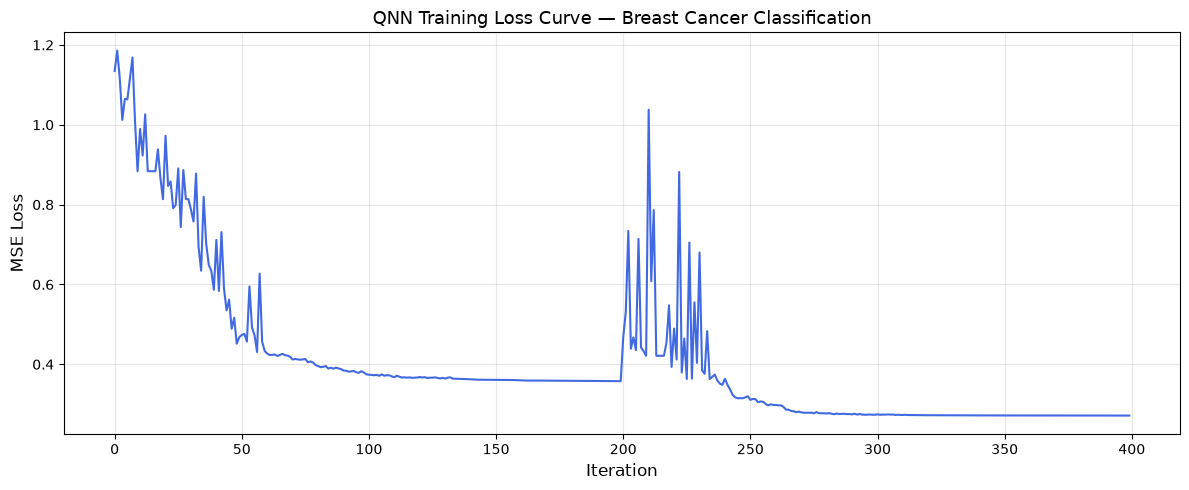

Total iterations  : 400
Starting loss     : 1.134538
Final loss        : 0.271549
Loss reduced by   : 76.1%


In [22]:
# Plot the loss curve
plt.figure(figsize=(12, 5))
plt.plot(objective_func_vals, color='royalblue', linewidth=1.5)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("QNN Training Loss Curve — Breast Cancer Classification", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("qnn_loss_curve.png", dpi=150)
plt.show()

print(f"Total iterations  : {len(objective_func_vals)}")
print(f"Starting loss     : {objective_func_vals[0]:.6f}")
print(f"Final loss        : {objective_func_vals[-1]:.6f}")
print(f"Loss reduced by   : {((objective_func_vals[0] - objective_func_vals[-1]) / objective_func_vals[0] * 100):.1f}%")

##  Evaluate QNN Accuracy

We now test our trained QNN on:
1. **Training set** — patients it learned from
2. **Test set** — patients it has never seen before

Predictions are converted:
- Output **≥ 0** → predict **Benign (+1)**
- Output **< 0** → predict **Malignant (-1)**

We use **Accuracy Score** to measure performance:
$$Accuracy = \frac{\text{Correct Predictions}}{\text{Total Patients}} \times 100$$

In [ ]:

print("Evaluating on training set...")

pred_train = forward(
    full_circuit,
    np.array(X_train),
    weight_params,
    estimator,
    observable
)

# Convert raw predictions to labels
pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] =  1
pred_train_labels[pred_train_labels <  0] = -1

train_accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Training Accuracy : {train_accuracy * 100:.1f}%")


print("\nEvaluating on test set...")

pred_test = forward(
    full_circuit,
    np.array(X_test),
    weight_params,
    estimator,
    observable
)

# Convert raw predictions to labels
pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] =  1
pred_test_labels[pred_test_labels <  0] = -1

test_accuracy = accuracy_score(test_labels, pred_test_labels)
print(f"Test Accuracy     : {test_accuracy * 100:.1f}%")


print("\n========== FINAL RESULTS ==========")
print(f"Dataset           : Breast Cancer Wisconsin")
print(f"Patients trained  : {len(X_train)}")
print(f"Patients tested   : {len(X_test)}")
print(f"Qubits used       : {num_qubits}")
print(f"Trainable weights : {ansatz.num_parameters}")
print(f"Final loss        : {objective_func_vals[-1]:.6f}")
print(f"Training Accuracy : {train_accuracy * 100:.1f}%")
print(f"Test Accuracy     : {test_accuracy * 100:.1f}%")
print("====================================")

Evaluating on training set...
Training Accuracy : 87.5%

Evaluating on test set...
Test Accuracy     : 87.5%

========== FINAL RESULTS ==========
Dataset           : Breast Cancer Wisconsin
Patients trained  : 64
Patients tested   : 16
Qubits used       : 4
Trainable weights : 16
Final loss        : 0.271549
Training Accuracy : 87.5%
Test Accuracy     : 87.5%
